     Latest: Time (s)  Latest: Position (m)  Latest: Velocity (m/s)  \
0                0.02              0.106459                0.005314   
1                0.04              0.106666                0.000494   
2                0.06              0.106493               -0.002319   
3                0.08              0.106407                0.001558   
4                0.10              0.106631                0.002524   
..                ...                   ...                     ...   
495              9.92              0.005500                0.027456   
496              9.94              0.005845                0.011149   
497              9.96              0.005896               -0.002591   
498              9.98              0.005655               -0.012767   
499             10.00              0.005207               -0.018714   

     Latest: Acceleration (m/s²)  
0                      -0.194527  
1                      -0.122090  
2                      -0.005777  
3      

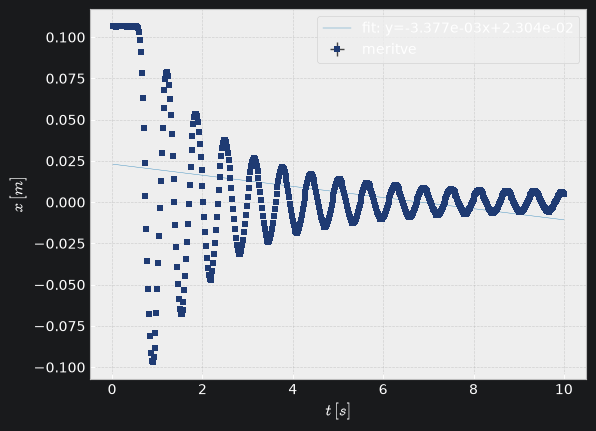

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd

plt.style.use('bmh') #ZELO DOBER PRESET!!!

df = pd.read_csv("meritve/TajMeritve/Meritev1.csv", delimiter=";", decimal=",")

print(df)
#PAZI!!! PRVA VRSTA SE NE UPOSTEVA !!!!
x = df.iloc[:,0].to_numpy()
y = df.iloc[:,1].to_numpy()
# y_cal = df.iloc[:,5].to_numpy()
# x_err = df.iloc[:,2].to_numpy()
# y_err = df.iloc[:,3].to_numpy()

print(x); print(y);

# fit function
def f(x, a, b):
    return a*x + b

# Fit
params, cov = curve_fit(f, x, y)
a, b = params
errors = np.sqrt(np.diag(cov))

# Plot

#wow:
plt.errorbar(
    x, y,
    yerr=0,
    xerr=0,
    fmt='s',  # square markers
    markersize=4,  # smaller dots
    color='#1f3b73',  # dark blue (markers + line)
    ecolor='#444444',  # dark grey error bars
    elinewidth=1,  # thin error lines
    capsize=3,  # "T" caps size
    capthick=1,  # thickness of caps
    markeredgewidth=0,
    linestyle='none',  # no connecting lines
    label='meritve'
)

x_fit = np.linspace(min(x), max(x), 100)
plt.plot(x_fit, f(x_fit, a, b), label=f'fit: y={a:.3e}x+{b:.3e}', linewidth=0.3)

plt.legend()
plt.xlabel(r"$t\,[s]$")
plt.ylabel(r"$x\,[m]$")
plt.savefig("graf1test.png", dpi=300, bbox_inches='tight')

print("a =", a)
print("b =", b)

#neke

